In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages

from langchain_community.tools import WikipediaQueryRun, DuckDuckGoSearchRun
from langchain_community.utilities import WikipediaAPIWrapper

from typing import TypedDict, Annotated

from dotenv import load_dotenv
load_dotenv()

True

In [2]:
model = ChatGroq(model="llama-3.1-8b-instant")

In [3]:
class agentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [4]:
# Wikipedia tool with wrapper
wiki_wrapper = WikipediaAPIWrapper(top_k_results=1)
wikipedia_tool = WikipediaQueryRun(api_wrapper=wiki_wrapper)

# DuckDuckGo web search
duckduckgo_tool = DuckDuckGoSearchRun()

In [5]:
@tool
def search_duck(query: str) -> str:

    """
    Use the tool for latest news, such as AI news, stock prices, sports results, current government policies, tec,.
    """
    response = DuckDuckGoSearchRun(query)
    return {'messages':response}

@tool
def search_wikipedia(query: str) -> str:
    """
    Search Wikipedia for factual information about people, events, or concepts.
    """
    response = wikipedia_tool(query)
    return {'messages':response}

llm_with_tools = model.bind_tools([search_wikipedia, search_duck])

In [6]:
system_prompt = """
    "You are a helpful AI assistant.\n"
    "Answer general questions by yourself.\n"
    "If the user asks for factual info, trending news, or math, "
    "use the available tools (Wikipedia, DuckDuckGo)."
"""

def chat_mode(state: agentState):
    """LLM node that may answer or request a tool call."""
    messages = [{"role": "system", "content": system_prompt}] + state.get("messages", [])

    response = llm_with_tools.invoke(messages)
    return {'messages':response}

In [7]:
tool_node = ToolNode([search_wikipedia, search_duck])

In [8]:
graph = StateGraph(agentState)


graph.add_node('chat_mode', chat_mode)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_mode')
graph.add_conditional_edges('chat_mode', tools_condition)

graph.add_edge('tools', 'chat_mode')

workflow = graph.compile()

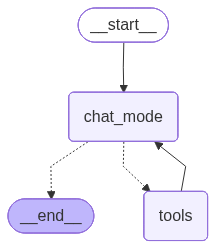

In [9]:
workflow

In [10]:
state = {'messages':"where is india located, who won the latest icc world cup"}

workflow.invoke(state)

C:\Users\ABCOM\AppData\Local\Temp\ipykernel_7768\2234419287.py:15: LangChainDeprecationWarning: The method `BaseTool.__call__` was deprecated in langchain-core 0.1.47 and will be removed in 1.0. Use :meth:`~invoke` instead.
  response = wikipedia_tool(query)


{'messages': [HumanMessage(content='where is india located, who won the latest icc world cup', additional_kwargs={}, response_metadata={}, id='fdf342ee-e443-4c27-9de6-05d3b1519ab6'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'q5sn3d7d4', 'function': {'arguments': '{"query":"India location"}', 'name': 'search_wikipedia'}, 'type': 'function'}, {'id': 'dye5s0t63', 'function': {'arguments': '{"query":"Latest ICC World Cup winner"}', 'name': 'search_wikipedia'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 377, 'total_tokens': 411, 'completion_time': 0.041053755, 'completion_tokens_details': None, 'prompt_time': 0.022015023, 'prompt_tokens_details': None, 'queue_time': 0.045335857, 'total_time': 0.063068778}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--019cd915-f0a4-75f2-9db6-d19c05272990-0', to